## Diabetes Regression Analysis

In this project, we used the diabetes dataset from scikit-learn, which contains patient features such as age, BMI, and blood pressure, along with a target variable representing disease progression after one year.

We applied multiple regression models, including Linear Regression, Ridge, Lasso, and SGDRegressor, to predict the target variable. Before modeling, we performed feature scaling to ensure all variables were on a similar scale, improving model performance.

We evaluated each model using Mean Squared Error (MSE) and R². The results showed that Lasso and Linear Regression performed the best, with very similar accuracy, while SGDRegressor performed the worst.

Overall, this analysis demonstrates how different regression techniques and preprocessing steps impact predictive performance.

In [77]:
import numpy as np 
from sklearn import datasets
import pandas as pd 

In [78]:
diabetes = datasets.load_diabetes()
print(diabetes.DESCR)

.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log of serum triglycerides level
    - s6      glu, blood sugar level

Note: Each of these 10 feature variables have bee

In [79]:
print(diabetes.feature_names)

['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


In [80]:
X = diabetes.data
Y = diabetes.target

In [81]:
print(X.shape)
print(Y.shape)

(442, 10)
(442,)


In [82]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size=.2)

In [83]:
from sklearn.preprocessing import StandardScaler

## We do fit_transform on training data because we want to learn the data. We dont want to learn the test data. 
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
## We will test different regression models to evaluate best ones
from sklearn.linear_model import SGDRegressor, Ridge, Lasso, LinearRegression
from sklearn.model_selection import GridSearchCV

## Finding optimal parameters 
param_grid = {
    'eta0': [.001, .01, .1],
    'max_iter': [500, 1000, 2000], 
    'learning_rate': ['constant', 'optimal']
}

SGD = GridSearchCV(SGDRegressor(), param_grid, cv=5)
SGD.fit(X_train, Y_train)
SGD_PRED = SGD.predict(X_test)

## Ridge and Lasso 
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, Y_train)
ridge_pred = ridge.predict(X_test)

lasso = Lasso(alpha=1.0)
lasso.fit(X_train, Y_train)
lasso_pred = lasso.predict(X_test)

# Normal Linear Model 
lr = LinearRegression()
lr.fit(X_train, Y_train)
lr_pred = lr.predict(X_test)

In [85]:
from sklearn.metrics import mean_squared_error, r2_score
results = pd.DataFrame({
    "Model": ["SGDRegressor", "Ridge", "Lasso", "Linear Regression"],
    "MSE": [
        mean_squared_error(Y_test, SGD_PRED),
        mean_squared_error(Y_test, ridge_pred),
        mean_squared_error(Y_test, lasso_pred),
        mean_squared_error(Y_test, lr_pred)
    ],
    "R2": [
        r2_score(Y_test, SGD_PRED),
        r2_score(Y_test, ridge_pred),
        r2_score(Y_test, lasso_pred),
        r2_score(Y_test, lr_pred)
    ]
})

results

,Model,MSE,R2
0,SGDRegressor,3352.880981,0.413219
1,Ridge,3320.654055,0.418859
2,Lasso,3268.066057,0.428062
3,Linear Regression,3339.920912,0.415487


In [88]:
## Lasso Regression has the best performance so we wil use that 

Y_pred = lasso_pred

Text(0.5, 1.0, 'Actual Vs Predicted')

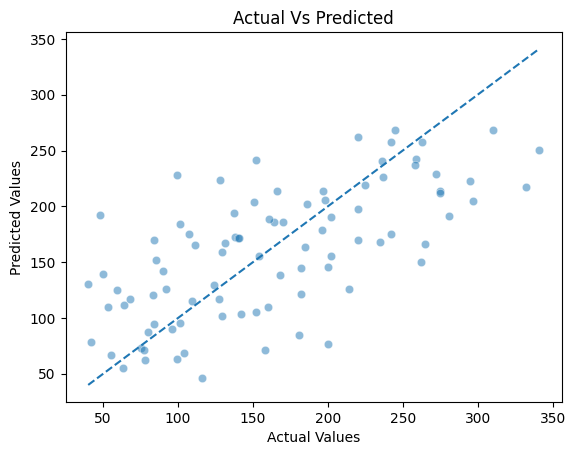

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x=Y_test, y=Y_pred, alpha=.5)

plt.plot([Y_test.min(), Y_test.max()],
         [Y_test.min(), Y_test.max()],
         linestyle='--')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual Vs Predicted")